<a href="https://www.arduino.cc/"><img src="https://raw.githubusercontent.com/sandeepmistry/aimldevfest-workshop-2019/master/images/Arduino_logo_R_highquality.png" width=200/></a>
# Tiny ML on Arduino
## Gesture recognition tutorial
 * Sandeep Mistry - Arduino
 * Don Coleman - Chariot Solutions


https://github.com/arduino/ArduinoTensorFlowLiteTutorials/

In [3]:
on_drive = False 
if on_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = ''
    output_path = ''
else:
    base_path = 'data-gesures/'
    output_path = 'scratch/'

## Setup Python Environment

In [4]:
#prints the path of the virtual environment
import sys
print(sys.executable)
# Setup environment
!apt-get -qq install xxd
!pip install pandas numpy matplotlib
!pip install tensorflow


/home/alanmasu/Documenti/Low-Power_IoT/EMBEDDED-GESTURE-RECO/.venv/bin/python
/bin/bash: riga 1: apt-get: comando non trovato

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# Graph of gestures

We'll graph the input files on two separate graphs, acceleration and gyroscope, as each data set has different units and scale.

/tmp/ipykernel_395695/1398464428.py:22: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aX'], 'g.', label='x', linestyle='solid', marker=',')
/tmp/ipykernel_395695/1398464428.py:23: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "b." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aY'], 'b.', label='y', linestyle='solid', marker=',')
/tmp/ipykernel_395695/1398464428.py:24: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "r." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aZ'], 'r.', label='z', linestyle='solid', marker=',')


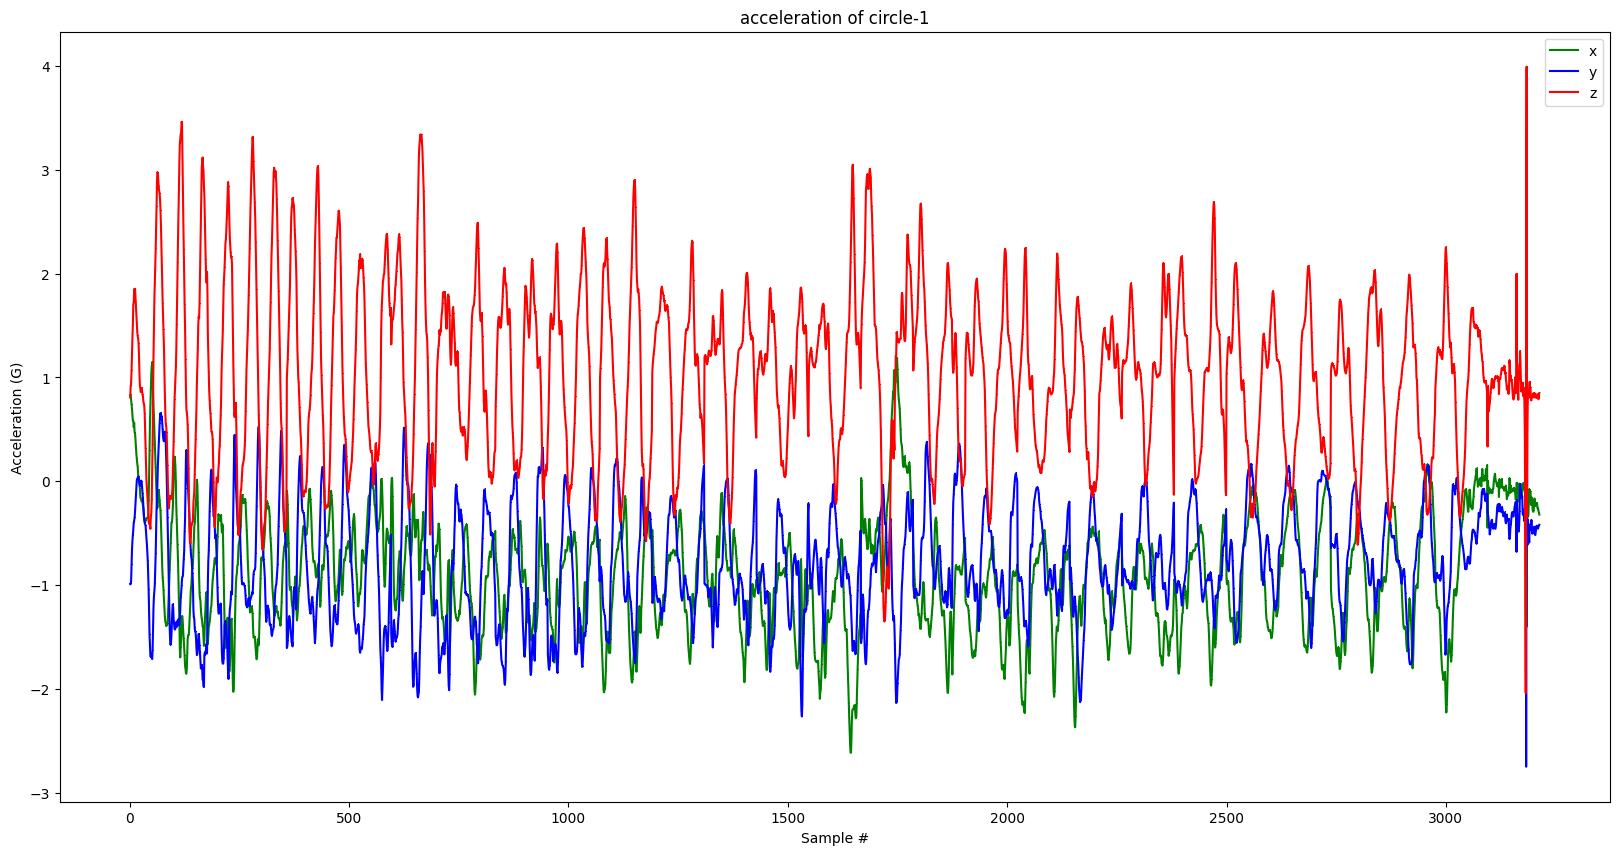

/tmp/ipykernel_395695/1398464428.py:31: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gX'], 'g.', label='x', linestyle='solid', marker=',')
/tmp/ipykernel_395695/1398464428.py:32: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "b." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gY'], 'b.', label='y', linestyle='solid', marker=',')
/tmp/ipykernel_395695/1398464428.py:33: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "r." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gZ'], 'r.', label='z', linestyle='solid', marker=',')


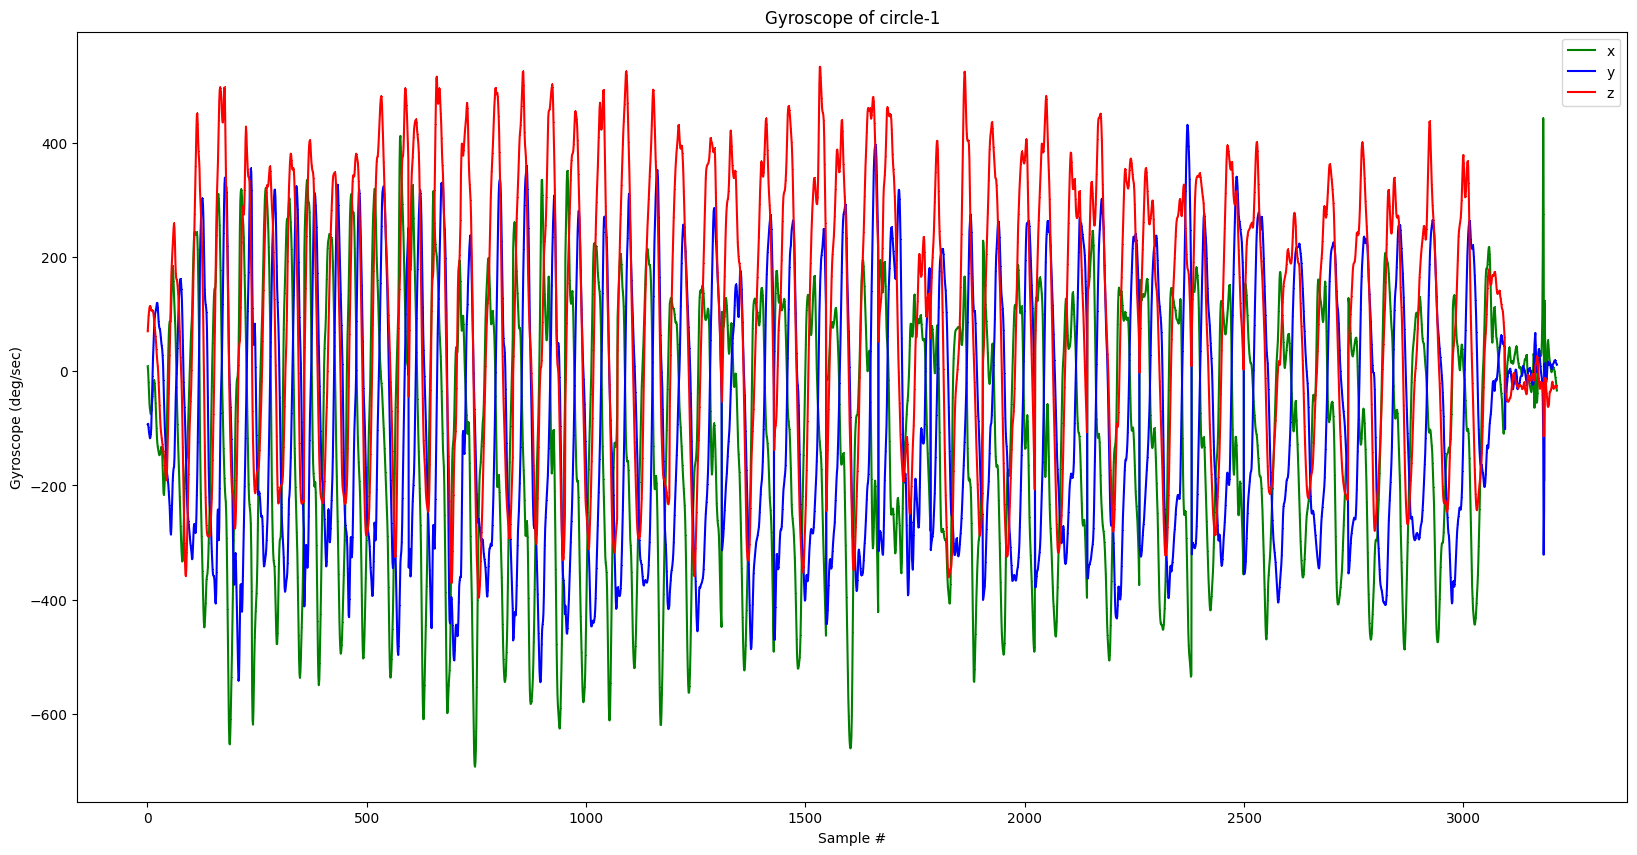

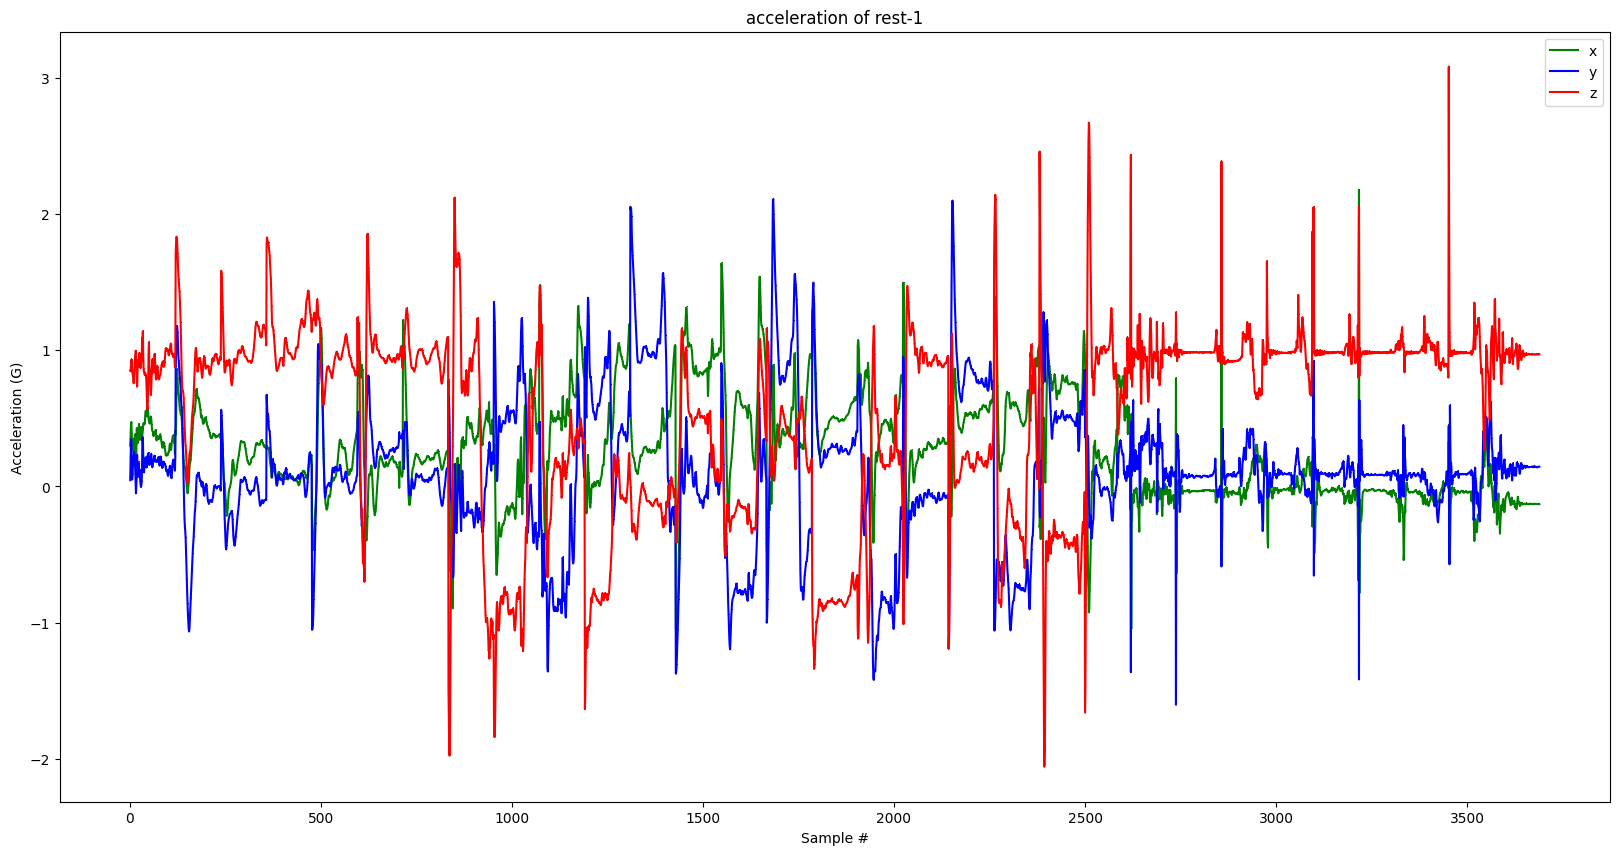

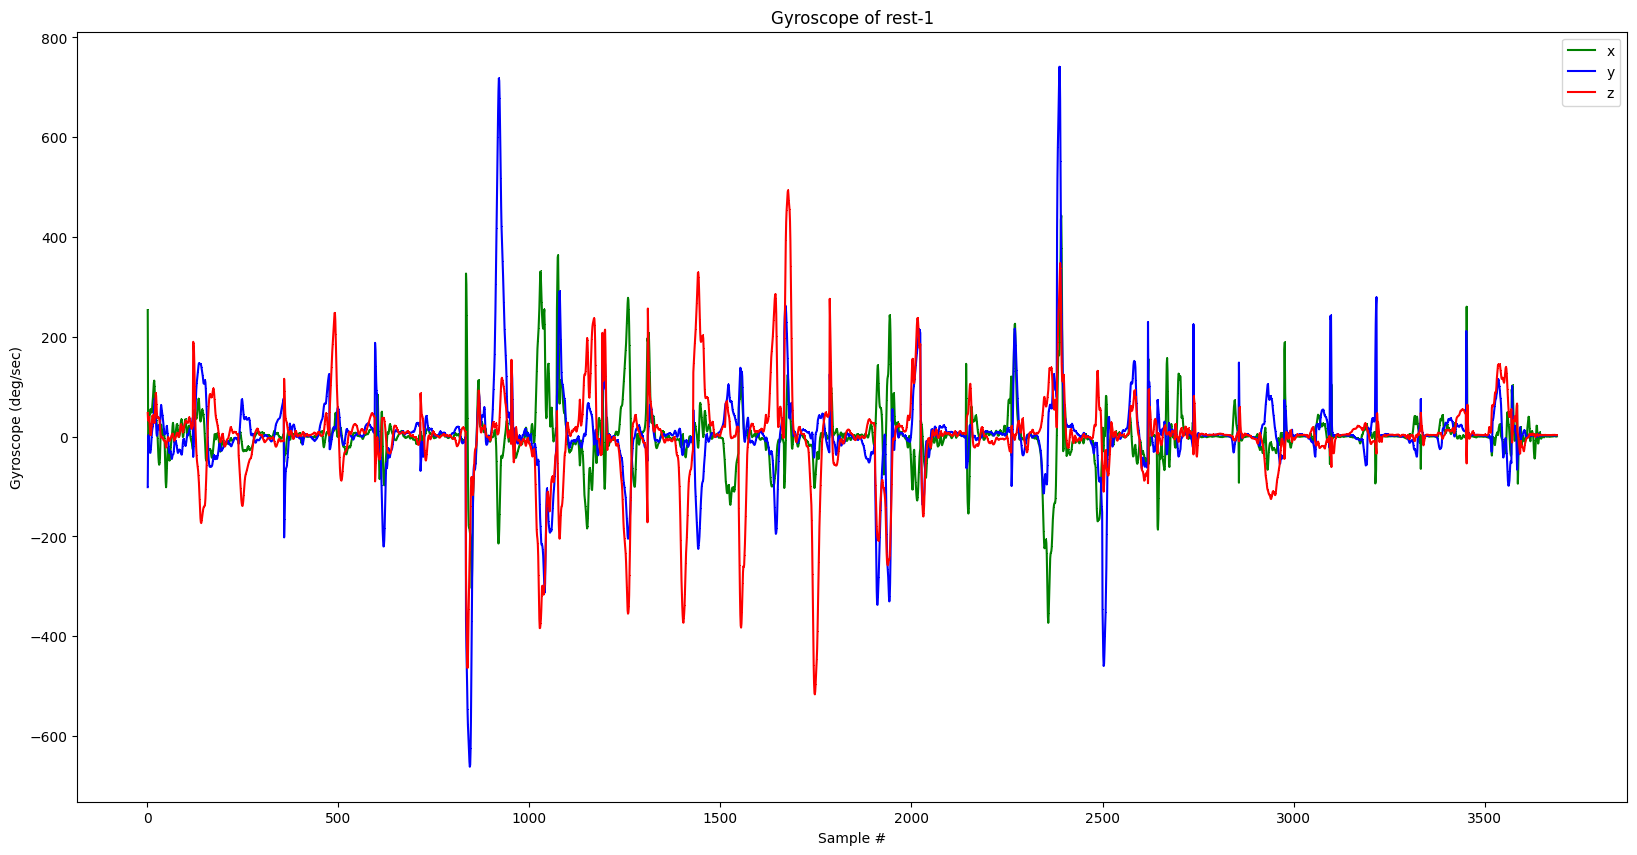

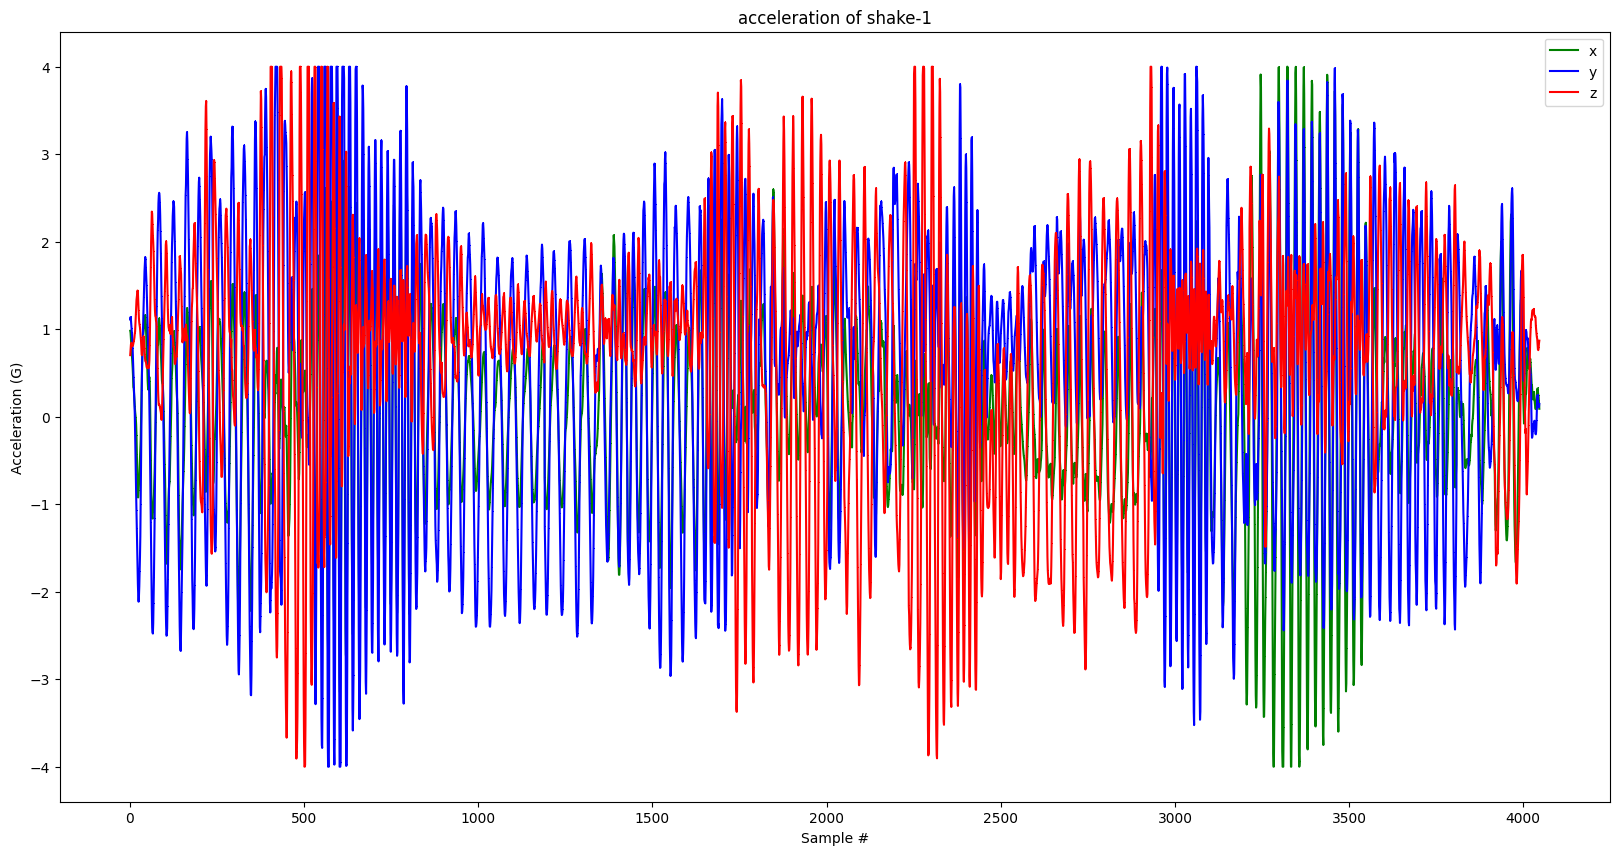

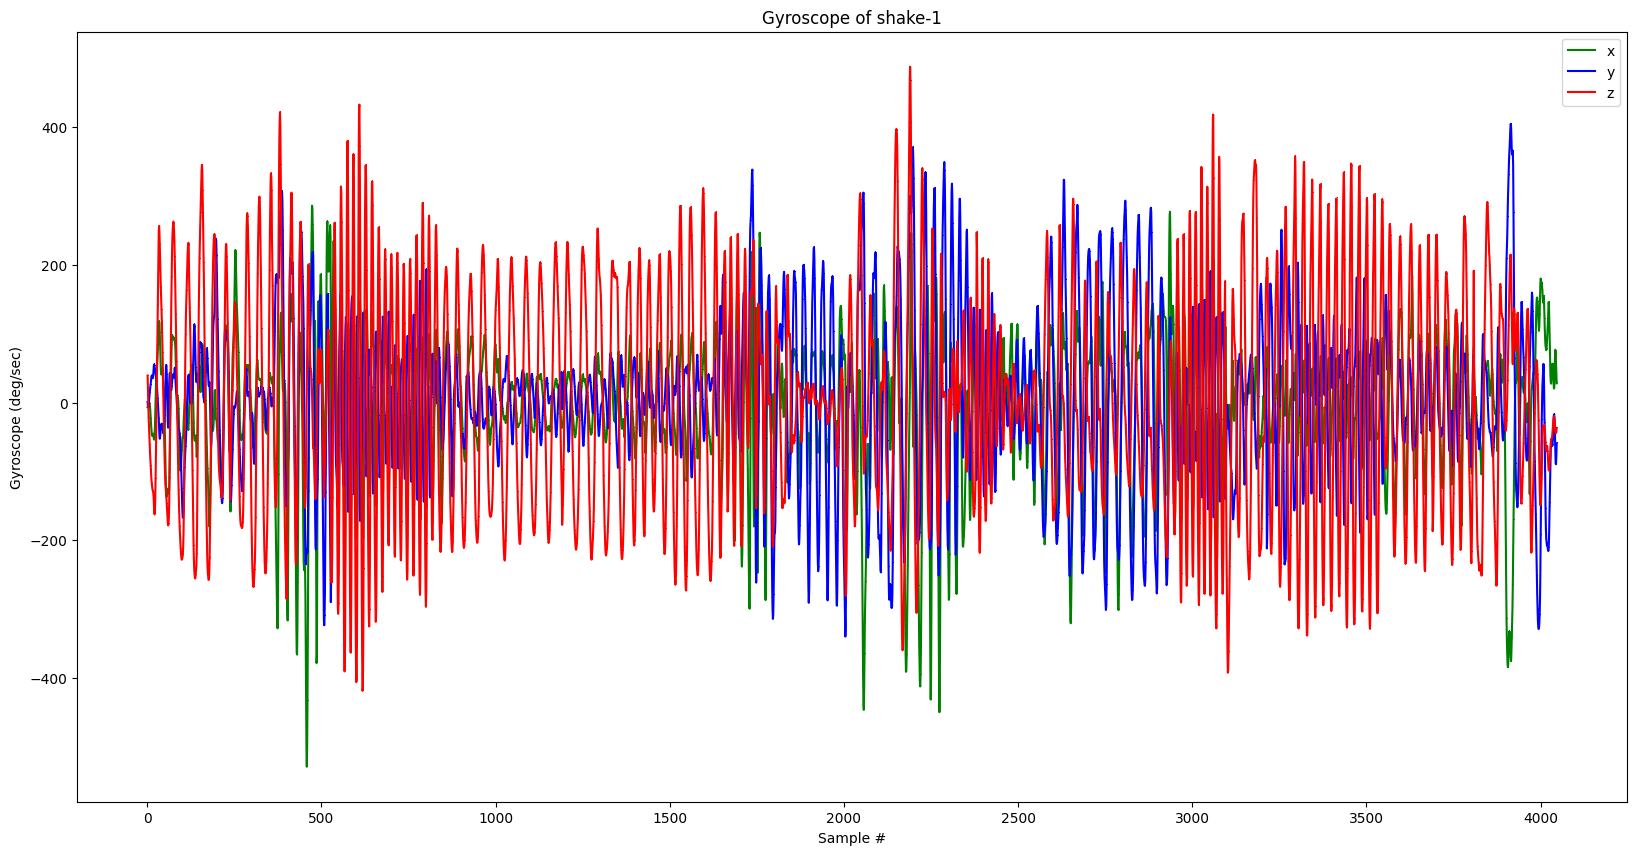

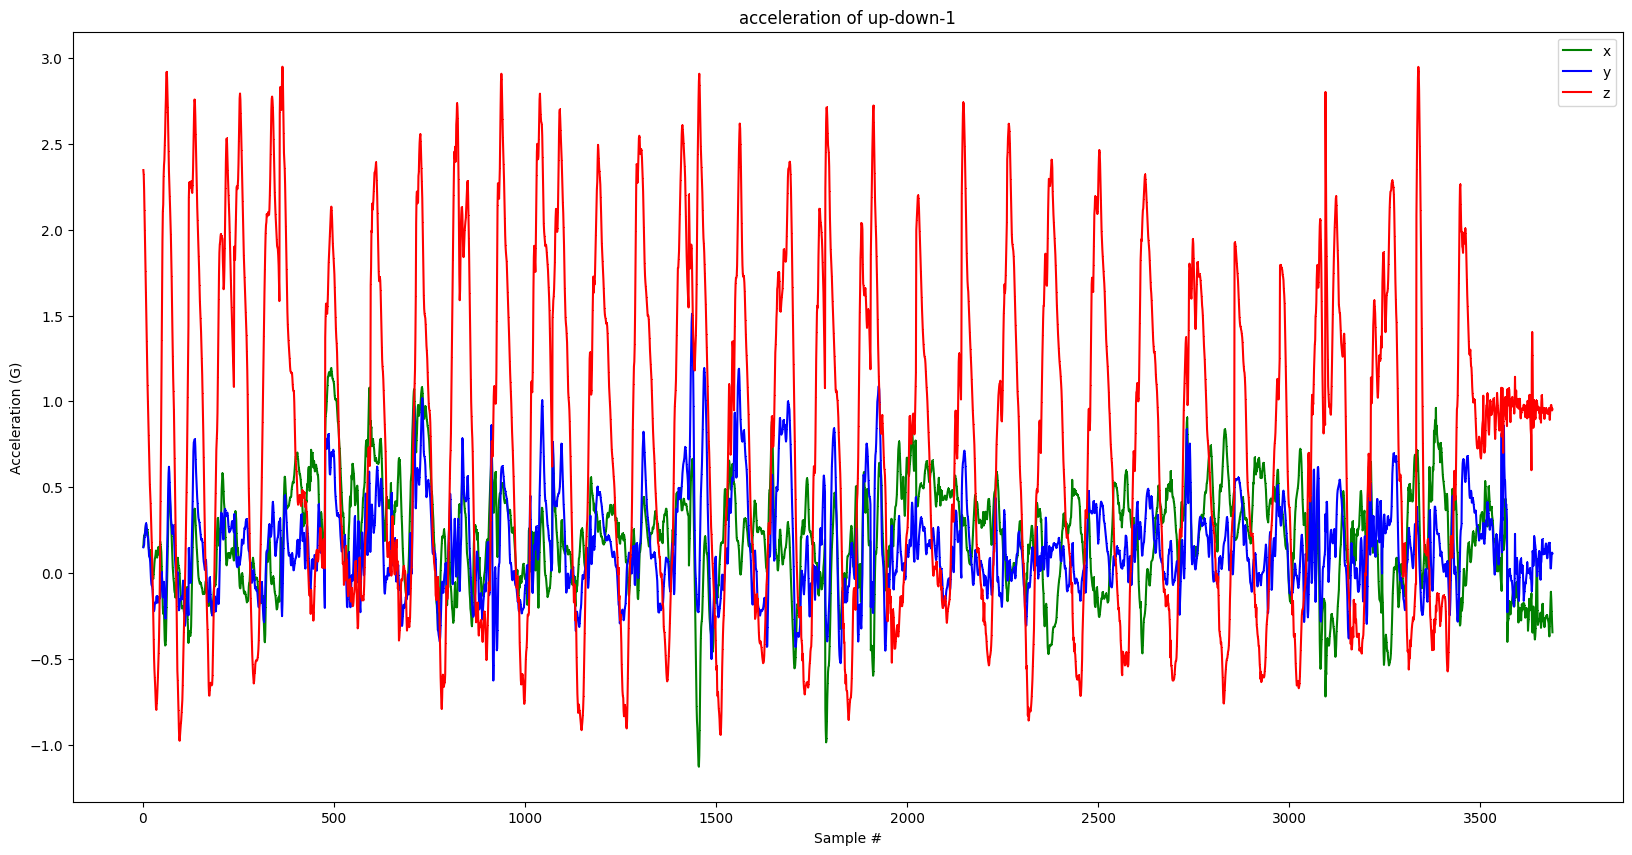

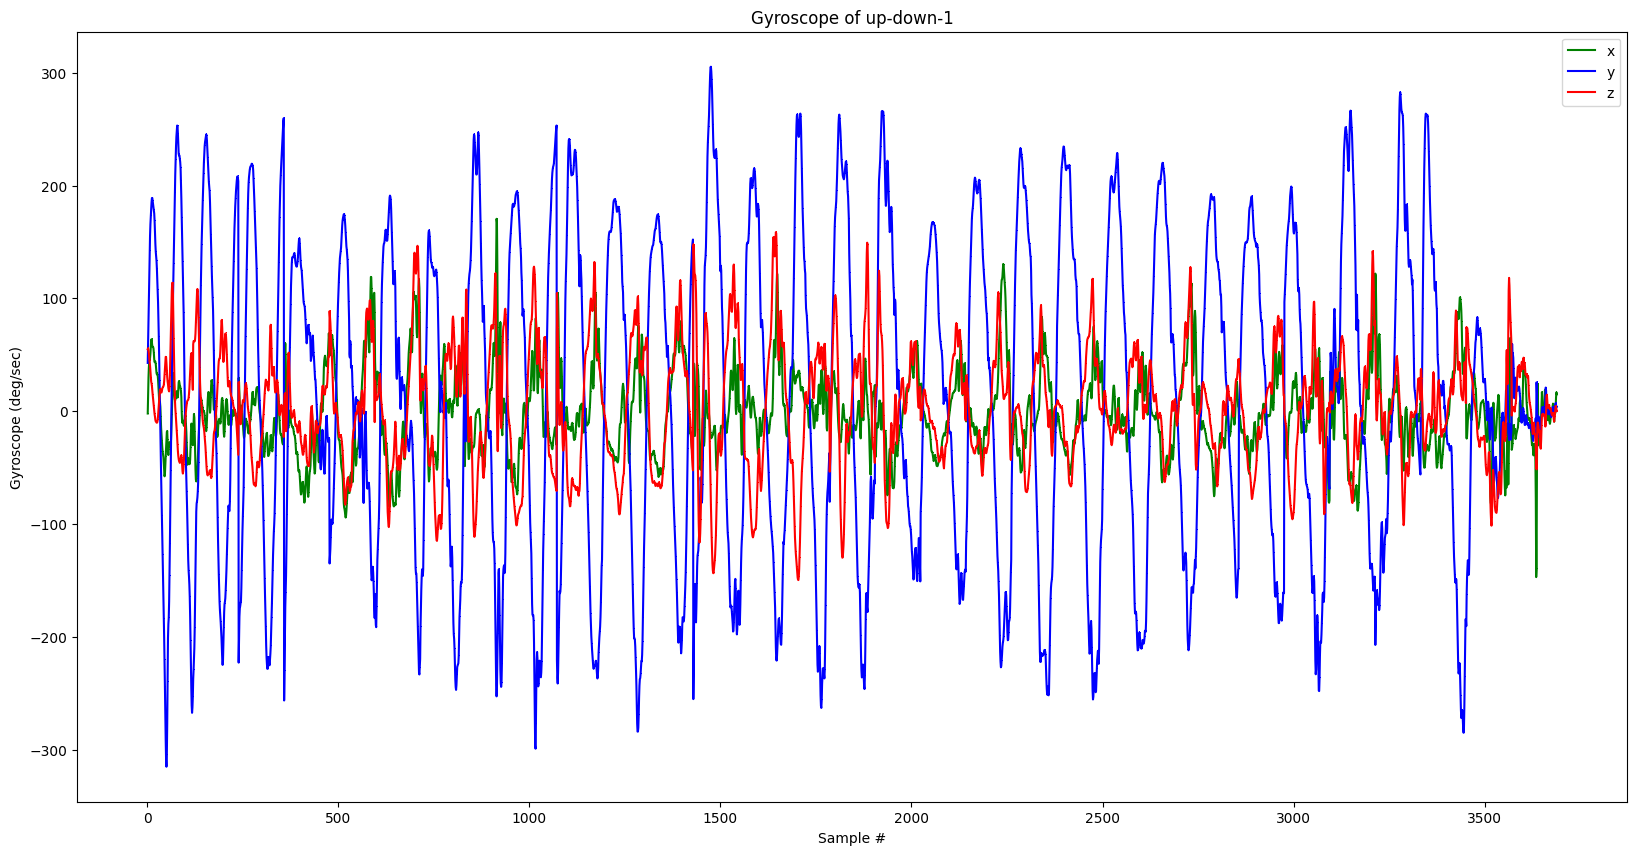

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# the list of gestures that data is available for
GESTURES = [
    "circle-1",
    "rest-1",
    "shake-1",
    "up-down-1"
]

for filename in GESTURES :
  name = base_path + filename + ".csv"

  df = pd.read_csv(name)

  index = range(1, len(df['aX']) + 1)

  plt.rcParams["figure.figsize"] = (20,10)

  plt.plot(index, df['aX'], 'g.', label='x', linestyle='solid', marker=',')
  plt.plot(index, df['aY'], 'b.', label='y', linestyle='solid', marker=',')
  plt.plot(index, df['aZ'], 'r.', label='z', linestyle='solid', marker=',')
  name = "acceleration of " + filename
  plt.title(name)
  plt.xlabel("Sample #")
  plt.ylabel("Acceleration (G)")
  plt.legend()
  plt.show()
  plt.plot(index, df['gX'], 'g.', label='x', linestyle='solid', marker=',')
  plt.plot(index, df['gY'], 'b.', label='y', linestyle='solid', marker=',')
  plt.plot(index, df['gZ'], 'r.', label='z', linestyle='solid', marker=',')
  name = "Gyroscope of " + filename
  plt.title(name)
  plt.xlabel("Sample #")
  plt.ylabel("Gyroscope (deg/sec)")
  plt.legend()

  plt.show()


# Extraction of features
We created a function `extract_features` which extract the features in the "window" we are looking at. We grouped the temporal and frequential features goether in a list called `features` of size $7 \times 6 = 42$. Where 7 is the number of features (5 for temporal and 2 for frequential) and 6 for the number of axes : `aX,aY,aZ,gX,gY,gZ` where `a`represents the acceleration and `g`the gyroscope.
Some eminder of formulas we used for different features:  
- The PSD (_Power Spectral Density_) is used here to normalize the power of the signal concerning the size of the frequency bin. The formula is : $PSD(f) = \frac{|f|^2}{Nf_s}$ where $N$ is the length of the signal and $f_s$ is the sampling frequency. We used here 1000hz
- The RMS (Root Mean Squaered) : $RMS = \sqrt{\frac{1}{N} \sum_{i=0}^N x_i^2}$, to simplify in our implementation we used the square-root of the mean which is clearer for the reader.

In [6]:
def extract_features(window : np.array) -> list :
  fs = 1000 #sampling frequency (arbitrary)
  features = [] #list of features
  for axis in window.T :
      #time domain

      mean = np.mean(axis)
      std = np.std(axis)
      rms = np.sqrt(np.mean(axis**2))
      minimum = np.min(axis)
      maximum = np.max(axis)

      #frequency domain
      signal_length = len(axis)
      fft = np.fft.rfft(axis) #fast fourier transformation (used by psd)
      psd = (np.abs(fft)**2)/(signal_length*fs) #power spectral density
      psd_mean = np.mean(psd)
      psd_max = np.max(psd)

      #regroup of the features
      features += [mean,std,rms,minimum,maximum,psd_mean,psd_max]

  return features


# Train Neural Network





In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

print(f"TensorFlow version = {tf.__version__}\n")

# Set a fixed random seed value, for reproducibility, this will allow us to get
# the same random numbers each time the notebook is run
SEED = 1563
np.random.seed(SEED)
tf.random.set_seed(SEED)



SAMPLES_PER_GESTURE = 142 #arbitrary selected

NUM_GESTURES = len(GESTURES) #number of gestures we have

# create a one-hot encoded matrix that is used in the output
ONE_HOT_ENCODED_GESTURES = np.eye(NUM_GESTURES)

inputs = []
outputs = []

# read each csv file and push an input and output

for gesture_index in range(NUM_GESTURES):
  gesture = GESTURES[gesture_index]
  print(f"Processing index {gesture_index} for gesture '{gesture}'.")

  output = ONE_HOT_ENCODED_GESTURES[gesture_index]

  df = pd.read_csv(base_path + gesture + ".csv")

  # calculate the number of gesture recordings in the file
  num_recordings = int(df.shape[0] / SAMPLES_PER_GESTURE)

  print(f"\tThere are {num_recordings} recordings of the {gesture} gesture.")

  for i in range(num_recordings):
    window = []
    for j in range(SAMPLES_PER_GESTURE):
      index = i * SAMPLES_PER_GESTURE + j
      # normalize the input data, between 0 to 1:
      # - acceleration is between: -4 to +4
      # - gyroscope is between: -2000 to +2000
      window.append([
          (df['aX'][index] + 4) / 8,
          (df['aY'][index] + 4) / 8,
          (df['aZ'][index] + 4) / 8,
          (df['gX'][index] + 2000) / 4000,
          (df['gY'][index] + 2000) / 4000,
          (df['gZ'][index] + 2000) / 4000
      ])
      #we choose to use the "append" instead of the
      #+= operator to show that it is a python array.
    window = np.array(window)
    #compute features
    features = extract_features(window)
    inputs.append(features)
    outputs.append(output)

# convert the list to numpy array
inputs = np.array(inputs)
outputs = np.array(outputs)
print("Data set parsing and preparation complete.")

print("Input shape:", inputs.shape)
print("Output shape:", outputs.shape)

print("Data set parsing and preparation complete.")

I0000 00:00:1774016950.636782  395695 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774016950.637203  395695 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774016950.671216  395695 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774016951.646648  395695 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow version = 2.21.0

Processing index 0 for gesture 'circle-1'.
	There are 22 recordings of the circle-1 gesture.
Processing index 1 for gesture 'rest-1'.
	There are 25 recordings of the rest-1 gesture.
Processing index 2 for gesture 'shake-1'.
	There are 28 recordings of the shake-1 gesture.
Processing index 3 for gesture 'up-down-1'.
	There are 25 recordings of the up-down-1 gesture.
Data set parsing and preparation complete.
Input shape: (100, 42)
Output shape: (100, 4)
Data set parsing and preparation complete.


## Parse and prepare the data

The next cell parses the csv files and transforms them to a format that will be used to train the Neural Network.
Here we consider a sample of `142`

Update the `GESTURES` list with the gesture data you've collected in `.csv` format.


## Randomize and split the input and output pairs for training

Randomly split input and output pairs into sets of data: 60% for training, 20% for validation, and 20% for testing.

  - the training set is used to train the model
  - the validation set is used to measure how well the model is performing during training
  - the testing set is used to test the model after training

In [8]:
# Randomize the order of the inputs, so they can be evenly distributed for training, testing, and validation
num_inputs = len(inputs)
randomize = np.arange(num_inputs)
np.random.shuffle(randomize)

# Swap the consecutive indexes (0, 1, 2, etc) with the randomized indexes
inputs = inputs[randomize]
outputs = outputs[randomize]

# Split the recordings (group of samples) into three sets: training, testing and validation
TRAIN_SPLIT = int(0.6 * num_inputs) #60% of our datas are for the training here
TEST_SPLIT = int(0.2 * num_inputs + TRAIN_SPLIT) #40% of our datas are for the testing phase

inputs_train, inputs_test, inputs_validate = np.split(inputs, [TRAIN_SPLIT, TEST_SPLIT])
outputs_train, outputs_test, outputs_validate = np.split(outputs, [TRAIN_SPLIT, TEST_SPLIT])

print("Data set randomization and splitting complete.")

Data set randomization and splitting complete.


## Build & Train the Model

We Build and train a [TensorFlow](https://www.tensorflow.org) model using the high-level [Keras](https://www.tensorflow.org/guide/keras) API.
Here

In [9]:
# build the model and train it
model = tf.keras.Sequential()
print("number of inputs : ", inputs.shape[1])
model.add(tf.keras.layers.Dense(42, activation='relu',input_shape=(inputs.shape[1],))) # relu is used for performance
#we add the input_shape to be more efficient for tensorflow here
#we define it with the number of inputs we computed above (6*7)
model.add(tf.keras.layers.Dense(15, activation='relu'))
model.add(tf.keras.layers.Dense(NUM_GESTURES, activation='softmax')) # softmax is used, because we only expect one gesture to occur per input
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
#loss : we use categorical_crossentropy adapted to classification with more than 2 classes
#metric : accuracy (for the same reason)
#optimizer : more modern, Adam (Adaptative Moment Estmiation), each weight has his own learning rate adaptative

history = model.fit(inputs_train, outputs_train, epochs=600, batch_size=8, validation_data=(inputs_validate, outputs_validate))
#For the batch_size we changed it by 8 because there is too much nooise at 1
#so 8 seems to be a good compromise to have a fast convergence.


number of inputs :  42
Epoch 1/600


/home/alanmasu/Documenti/Low-Power_IoT/EMBEDDED-GESTURE-RECO/.venv/lib64/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1774016952.565617  395695 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3000 - loss: 1.3862 - val_accuracy: 0.1000 - val_loss: 1.4508
Epoch 2/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3000 - loss: 1.3712 - val_accuracy: 0.1000 - val_loss: 1.4330
Epoch 3/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3000 - loss: 1.3626 - val_accuracy: 0.1000 - val_loss: 1.4159
Epoch 4/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3000 - loss: 1.3572 - val_accuracy: 0.1000 - val_loss: 1.4057
Epoch 5/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3000 - loss: 1.3520 - val_accuracy: 0.1000 - val_loss: 1.3958
Epoch 6/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3000 - loss: 1.3476 - val_accuracy: 0.1000 - val_loss: 1.3871
Epoch 7/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3000 - loss: 1.3424 - val_accuracy: 0.1000 - val_loss: 1.3784
Epoch 8/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3000 - loss: 1.3372 - val_accuracy: 0.1000 - val_loss: 1.3709
Epoch 9/600

## Verify

Graph the models performance vs validation.


### (TO DELETE OR ADAPT TO THE CORRECT LOSS FUNCTION ?) Graph the loss

Graph the loss to see when the model stops improving.

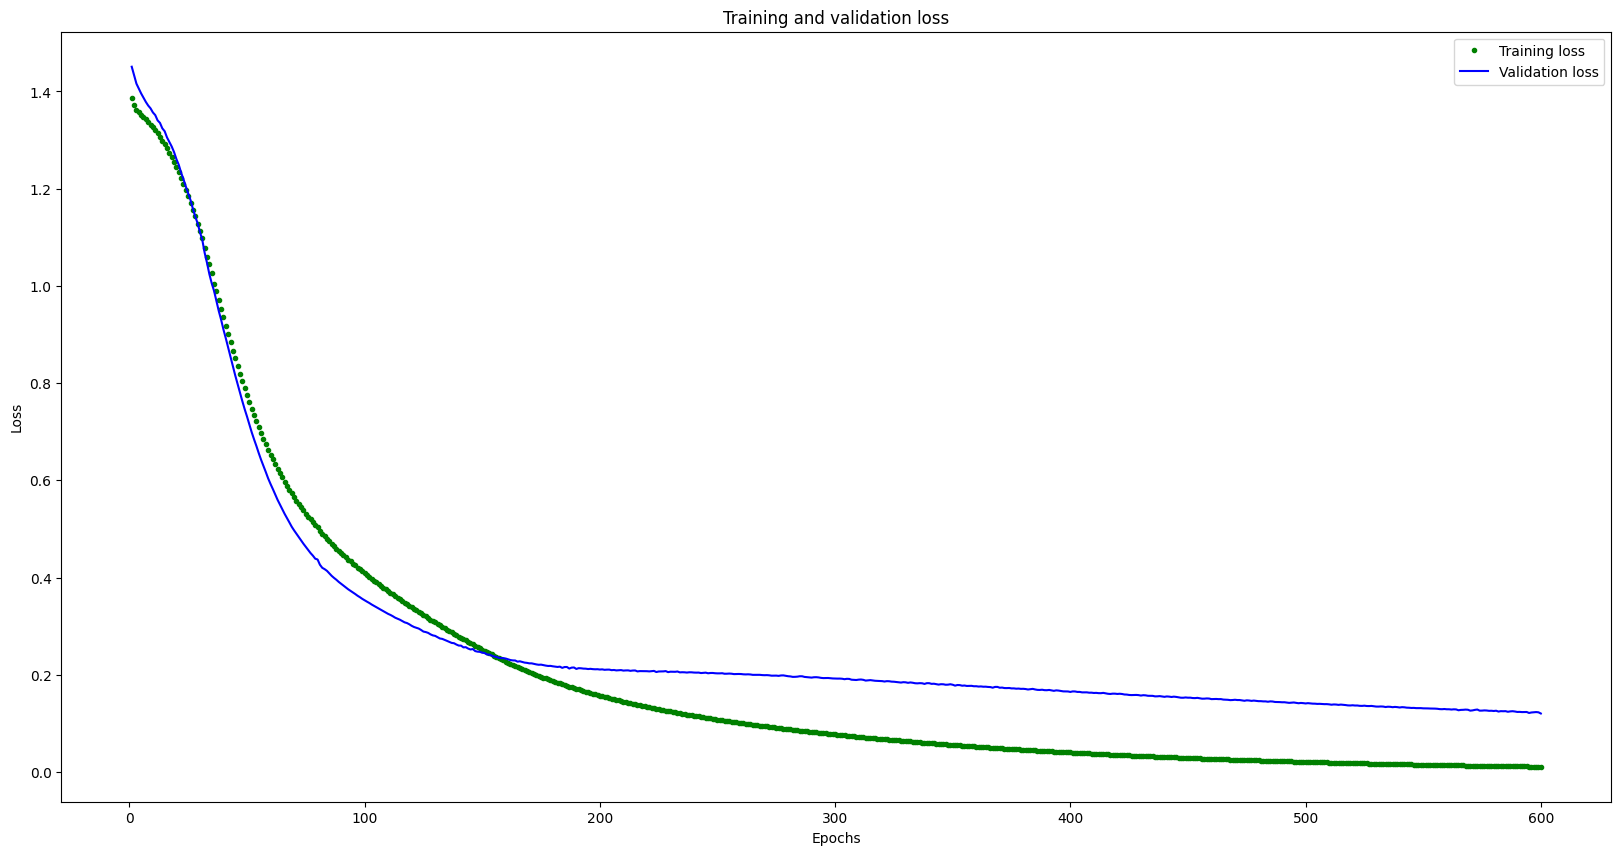

[20.0, 10.0]


In [10]:
# increase the size of the graphs. The default size is (6,4).
plt.rcParams["figure.figsize"] = (20,10)

# graph the loss, the model above is configure to use "mean squared error" as the loss function
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'g.', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(plt.rcParams["figure.figsize"])

### (TO DELETE OR ADAPT TO THE CORRECT LOSS FUNCTION ?) Graph the loss again, skipping a bit of the start

We'll graph the same data as the previous code cell, but start at index 100 so we can further zoom in once the model starts to converge.

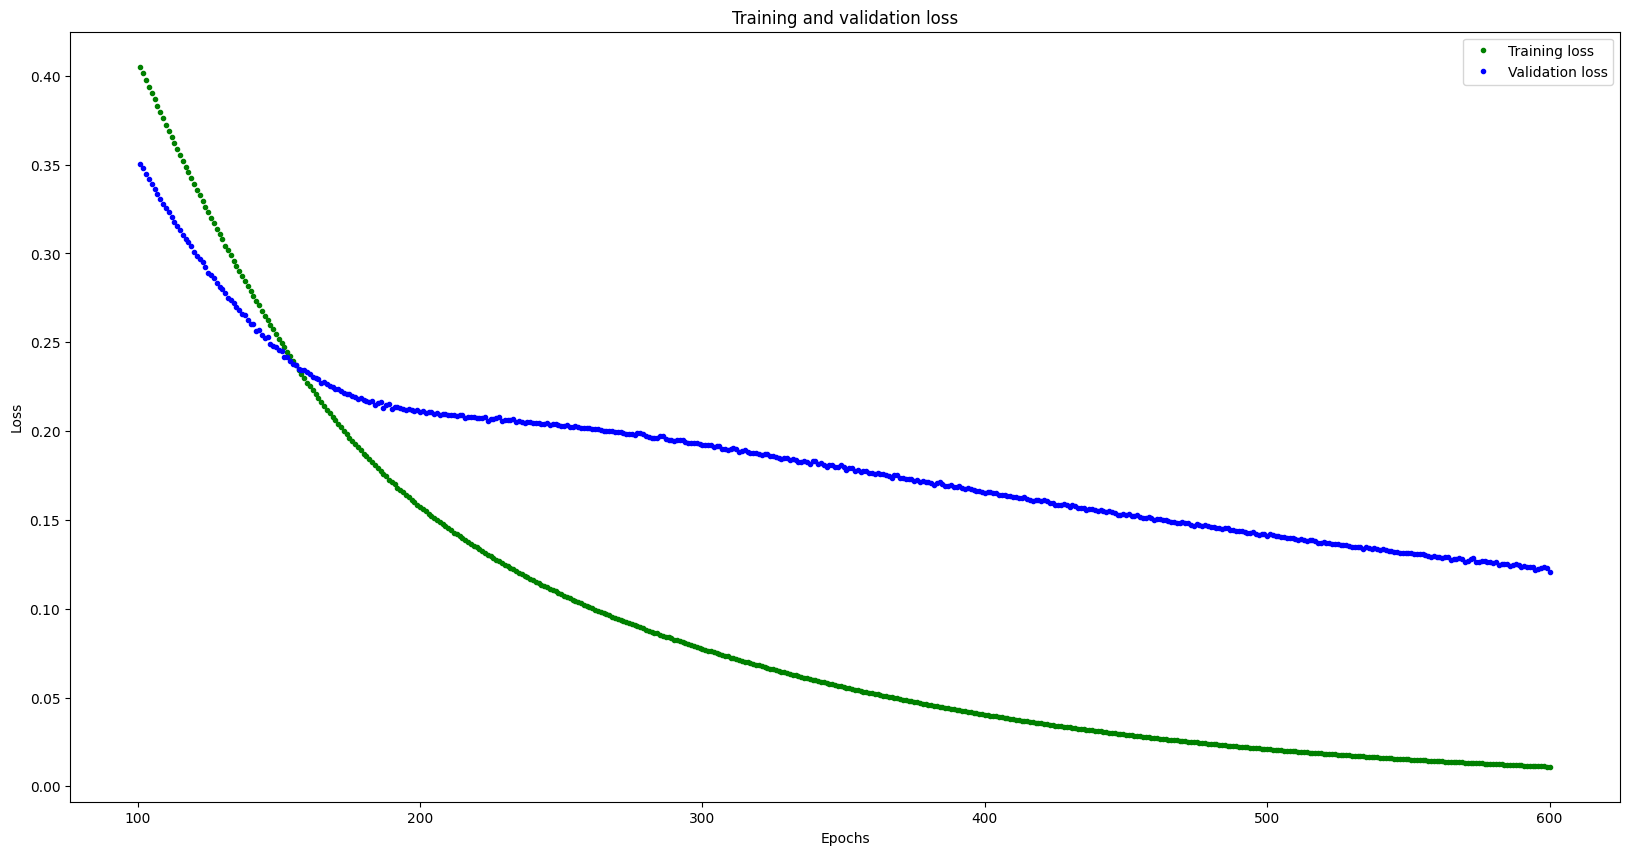

In [11]:
# graph the loss again skipping a bit of the start
SKIP = 100
plt.plot(epochs[SKIP:], loss[SKIP:], 'g.', label='Training loss')
plt.plot(epochs[SKIP:], val_loss[SKIP:], 'b.', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### (TO DELETE OR ADAPT TO THE CORRECT FUNCTION ?) Graph the mean absolute error

[Mean absolute error](https://en.wikipedia.org/wiki/Mean_absolute_error) is another metric to judge the performance of the model.



In [12]:
# # graph of mean absolute error
# mae = history.history['mae']
# val_mae = history.history['val_mae']
# plt.plot(epochs[SKIP:], mae[SKIP:], 'g.', label='Training MAE')
# plt.plot(epochs[SKIP:], val_mae[SKIP:], 'b.', label='Validation MAE')
# plt.title('Training and validation mean absolute error')
# plt.xlabel('Epochs')
# plt.ylabel('MAE')
# plt.legend()
# plt.show()


### Run with Test Data
Put our test data into the model and plot the predictions


In [13]:
# # use the model to predict the test inputs
# predictions = model.predict(inputs_test)

# # print the predictions and the expected ouputs
# print("predictions =\n", np.round(predictions, decimals=3))
# print("actual =\n", outputs_test)

# # Plot the predictions along with to the test data
# plt.clf()
# plt.title('Training data predicted vs actual values')
# plt.plot(inputs_test, outputs_test, 'b.', label='Actual')
# plt.plot(inputs_test, predictions, 'r.', label='Predicted')
# plt.show()

# Convert the Trained Model to Tensor Flow Lite

The next cell converts the model to TFlite format. The size in bytes of the model is also printed out.

In [14]:
# Check if the output directory exists, if not create it
import os
if not os.path.exists(output_path):
    os.makedirs(output_path)

# Convert the model to the TensorFlow Lite format without quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the model to disk
open(output_path + "gesture_model.tflite", "wb").write(tflite_model)

basic_model_size = os.path.getsize(output_path + "gesture_model.tflite")
print("Model is %d bytes" % basic_model_size)



INFO:tensorflow:Assets written to: /tmp/tmpg2mkc1rj/assets


INFO:tensorflow:Assets written to: /tmp/tmpg2mkc1rj/assets


Saved artifact at '/tmp/tmpg2mkc1rj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  140708783924112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140708783930640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140708782342416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140708782343184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140708782343568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140708782343952: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model is 12252 bytes


W0000 00:00:1774016995.206780  395695 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1774016995.206791  395695 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1774016995.206993  395695 reader.cc:83] Reading SavedModel from: /tmp/tmpg2mkc1rj
I0000 00:00:1774016995.207314  395695 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1774016995.207320  395695 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpg2mkc1rj
I0000 00:00:1774016995.210108  395695 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1774016995.210570  395695 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1774016995.229783  395695 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpg2mkc1rj
I0000 00:00:1774016995.235073  395695 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 28090 microseconds.
I0000 00:00:1774016995.246094  395695

## Encode the Model in an Arduino Header File

The next cell creates a constant byte array that contains the TFlite model. Import it as a tab with the sketch below.

In [17]:

def convert_tflite_to_header(tflite_path, header_path):
    # Reading the TFLite model file as binary data
    with open(tflite_path, 'rb') as f:
        data = f.read()

    with open(header_path, 'w') as f:
        # Write the header guard and the declaration of the model array
        f.write("const unsigned char model[] = {\n")
        
        # Converting each byte to hexadecimal format (0x00)
        # We put 12 bytes per line to keep the file readable
        hex_lines = []
        for i in range(0, len(data), 12):
            chunk = data[i:i + 12]
            hex_chunk = ", ".join([f"0x{b:02x}" for b in chunk])
            hex_lines.append("  " + hex_chunk)
        
        # Join the lines with a comma and newline
        f.write(",\n".join(hex_lines))
        
        # Close the array
        f.write("\n};\n")

# Conversion
convert_tflite_to_header(output_path + "gesture_model.tflite", output_path + "model.h")

import os
model_h_size = os.path.getsize(output_path + "model.h")
print(f"Header file, model.h, is {model_h_size:,} bytes.")
print("\nOpen the side panel (refresh if needed). Double click model.h to download the file.")

Header file, model.h, is 75,588 bytes.

Open the side panel (refresh if needed). Double click model.h to download the file.
